눈마사지기 데이터

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
font_path = "C:/Windows/Fonts/malgun.ttf"
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
from prophet import Prophet
from darts.models import VARIMA
from pmdarima import auto_arima
from darts.models import Croston
from darts import TimeSeries

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_excel('../data/merged_data_with_safety.xlsx')
df

,year,month,day,white,black,total,date,white_safety,black_safety,total_safety,white_with_safety,black_with_safety,total_with_safety
0,2023,8,1,8.0,1.0,9.0,2023-08-01,0,0,0,8.0,1.0,9.0
1,2023,8,2,13.0,1.0,14.0,2023-08-02,8,1,9,21.0,2.0,23.0
2,2023,8,3,10.0,0.0,10.0,2023-08-03,10,1,12,20.0,1.0,22.0
3,2023,8,4,14.0,0.0,14.0,2023-08-04,10,1,11,24.0,1.0,25.0
4,2023,8,5,0.0,0.0,0.0,2023-08-05,12,0,13,12.0,0.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,2025,2,24,2.0,23.0,25.0,2025-02-24,0,4,4,2.0,27.0,29.0
605,2025,2,25,2.0,11.0,13.0,2025-02-25,1,8,8,3.0,19.0,21.0
606,2025,2,26,0.0,6.0,6.0,2025-02-26,1,11,13,1.0,17.0,19.0
607,2025,2,27,0.0,4.0,4.0,2025-02-27,1,13,15,1.0,17.0,19.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   year               609 non-null    int64         
 1   month              609 non-null    int64         
 2   day                609 non-null    int64         
 3   white              578 non-null    float64       
 4   black              577 non-null    float64       
 5   total              578 non-null    float64       
 6   date               609 non-null    datetime64[ns]
 7   white_safety       609 non-null    int64         
 8   black_safety       609 non-null    int64         
 9   total_safety       609 non-null    int64         
 10  white_with_safety  578 non-null    float64       
 11  black_with_safety  577 non-null    float64       
 12  total_with_safety  578 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(6)
memory usage: 62.0 KB


# EDA

In [13]:
def plot_separate_time_series(df, cols):
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(cols, 1):
        plt.subplot(4, 1, i)
        plt.plot(df['date'], df[col], label=col, color='tab:blue')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.title(f'{col} over time')
        plt.grid(True)
        plt.tight_layout()

    plt.show()

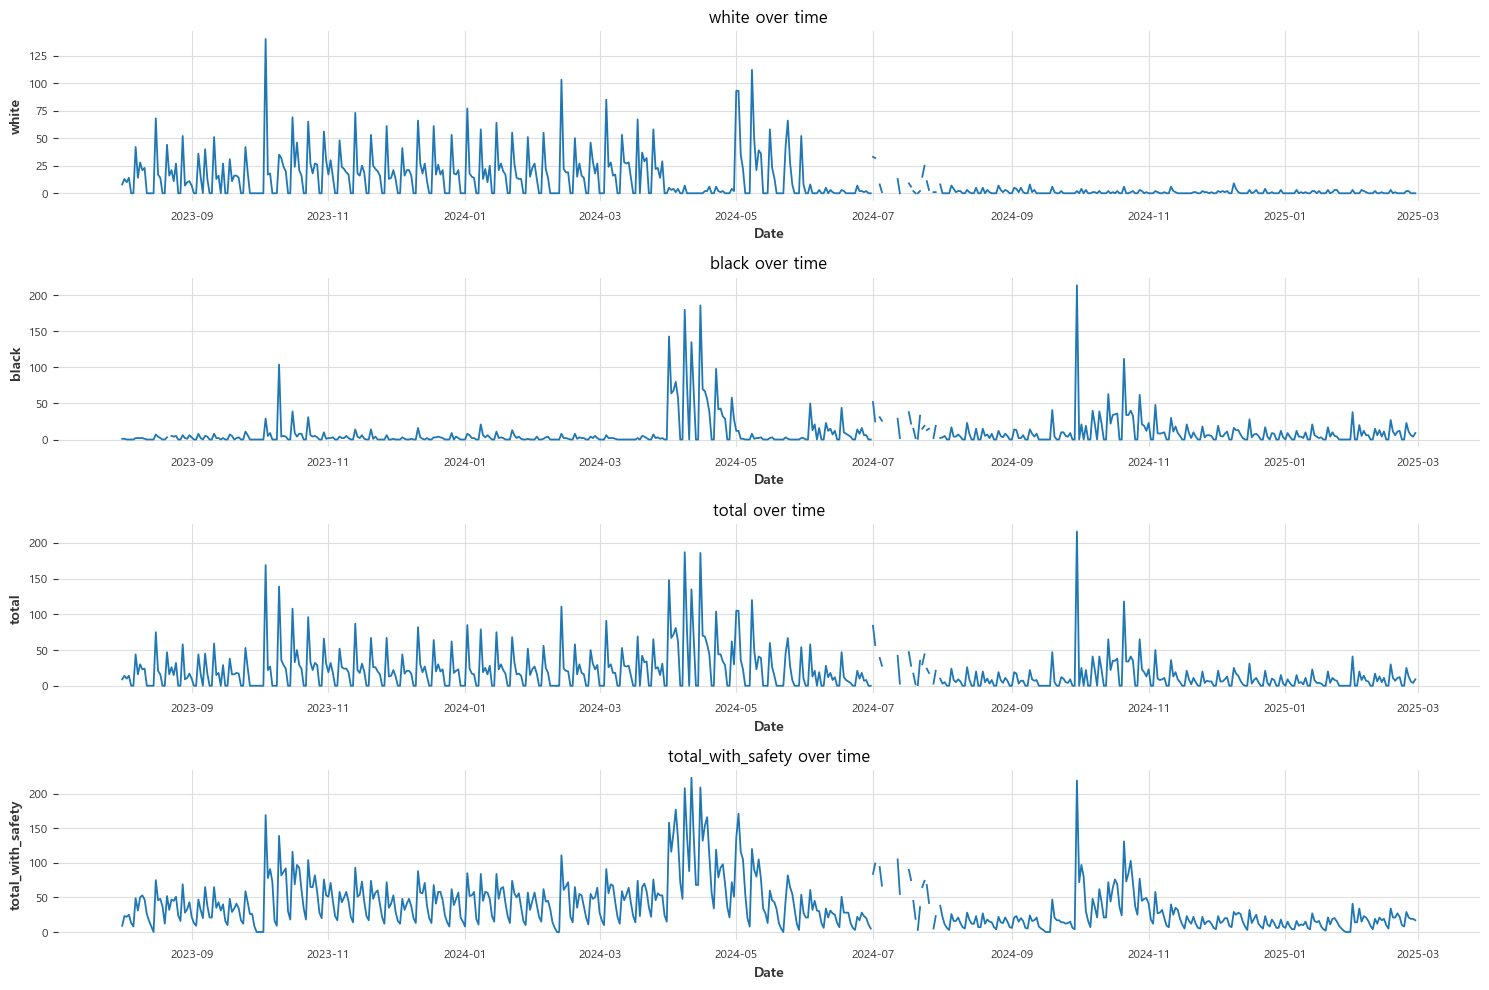

In [14]:
# 실행
plot_separate_time_series(df, ['white', 'black', 'total', 'total_with_safety'])

1. white over time
- 2023-08 ~ 2024-05: 수요가 자주 발생하고 진폭이 큼. 특히 2023년 10월경에 급격한 수요 피크(약 130 이상)가 있음.
- 2024-06 이후: 수요가 급감하거나 거의 0에 가까움, 가끔씩만 수요 발생. 간헐성 증가.
- 전반적 패턴:
  - 초기엔 활발한 수요 + 높은 진폭
  - 시간이 지날수록 수요가 줄어들고 간헐성이 심화됨
  - 시즌성은 뚜렷하지 않음, 다만 특정 시점에서 스파이크가 보임

2. black over time
- 2023-08 ~ 2024-03: 전반적으로 수요가 적고, 몇몇 시점에서만 튀어나옴 (예: 2023년 10월, 약 100 이상).
- 2024-04 ~ 2024-07: 상대적으로 빈도 높은 수요 + 큰 진폭 (200 이상) 발생.
- 2024-08 이후: 다시 간헐성 증가, 대부분 0 수요, 드물게 약한 피크.
- 전반적 패턴:
    - 불규칙한 수요 패턴 + 간헐적인 강한 피크
    - 특히 중간 구간에서 잠시 수요가 몰림 → 무언가 이벤트나 조건 발생 가능성
    - 시즌성보단 이벤트성 수요가 있는 느낌

3. total over time
- 2023-08 ~ 2024-06 초반까지: 비교적 규칙적인 패턴
  - 주기적인 피크 발생, 진폭은 점차 증가
  - 수요 자체는 꾸준히 존재
- 2024-06 ~ 2024-10: 수요가 갑작스럽게 급감하거나 사라짐
  - 간헐적인 값만 드문드문 발생
- 2024-10 ~ 2025-03: 간헐성이 매우 심해짐
    - 대부분 0 수요, 가끔 큰 피크 존재 (2024-10~11 사이 한 번 크게 튀는 값 있음)
- 전체적으로 보면:
  - 전반기: 안정된 반복적 수요 (계절성 또는 주기성 가능)
  - 후반기: 급격한 수요 감소 + 간헐성 심화

4. total_with_safety over time
- 기본적으로 total 시계열과 매우 유사한 패턴을 따름: 이유는 아마 total + safety stock 형태이기 때문으로 보임
- 차이점:
  - 전체적으로 total보다 진폭이 큼 (안전재고 때문)
  - 수요 급감 이후에도 total_with_safety는 더 부드럽게 감소
  - 완전히 0이 되기보다는, 작은 수요라도 유지되는 경향
  - 2024-06 이후: 간헐성은 있으나, total보다는 여전히 수요가 유지됨

# 1. Auto_ARIMA
- ARIMA 모델의 최적의 (p, d, q) 조합을 자동으로 찾아주는 함수

> 1. 차분 횟수 d를 테스트로 먼저 결정하고: ADF 테스트 (Augmented Dickey-Fuller Test) 또는 KPSS 테스트로 시계열이 정상인지 확인
2. 주어진 p, q 범위에서 가능한 조합을 시도해서
3. 각 (p, d, q) 조합으로 모델을 학습한 뒤, 가장 AIC(Akaike Information Criterion)/BIC(Bayesian Information Criterion)가 낮은 모델을 고름

### 0425 피드백
: 슬라이딩하면서 7일 간격 예측
- 초기 (p,d,q)를 고정하고, sliding 동안 계속 그걸로만 예측하기 → 더 빠르고, 일관성 있는 결과

In [15]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

def sliding_arima_forecast(df, col, test_ratio=0.2, window_size=7):
    df = df.set_index('date')
    series = df[col].fillna(0)
    
    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    # (1) 초기 train으로 p,d,q 구하기
    model_init = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True)
    p, d, q = model_init.order
    print(f"[{col}] 초기 고정된 ARIMA Order: ({p},{d},{q})")

    preds = []

    # (2) 슬라이딩 예측 시작
    history = train.copy()
    for i in range(0, len(test), window_size):
        end_idx = min(i + window_size, len(test))

        model = ARIMA(history, order=(p,d,q))
        model_fit = model.fit()

        pred = model_fit.forecast(steps=end_idx - i)
        preds.extend(pred)

        # history에 test 데이터 추가
        history = pd.concat([history, test.iloc[i:end_idx]])

    # (3) 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(test.index, test, label='Actual', color='black')
    plt.plot(test.index, preds, label='Forecast', color='red')
    plt.title(f'{col} - Sliding ARIMA Forecast (fixed order)')
    plt.legend()
    plt.grid(True)
    plt.show()


[white] 초기 고정된 ARIMA Order: (5,1,3)


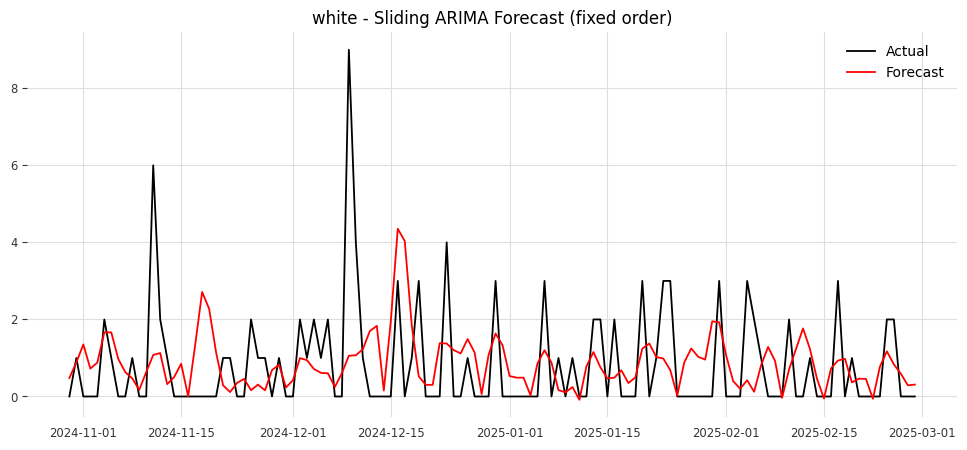

[black] 초기 고정된 ARIMA Order: (2,1,3)


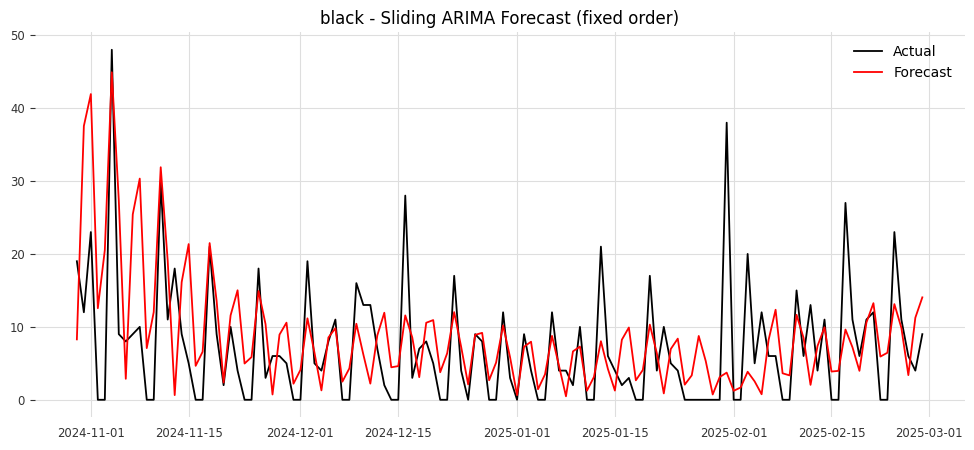

[total] 초기 고정된 ARIMA Order: (5,1,5)


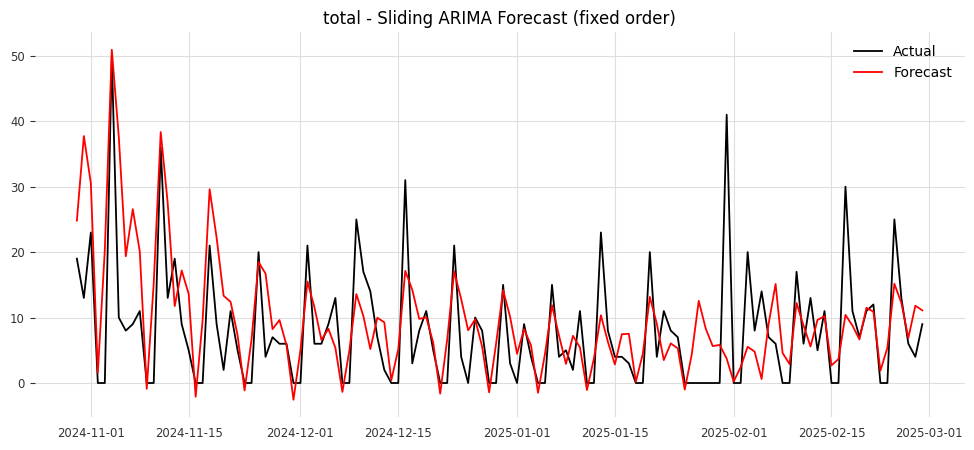

In [16]:
# 대상 컬럼별 반복 예측
target_cols = ['white', 'black', 'total']
for col in target_cols:
    sliding_arima_forecast(df.copy(), col)

# 2. Prophet
- 트렌드 + 계절성 + 휴일 효과 등을 자동으로 반영
- 데이터프레임이 ds(날짜), y(값) 형태
- Prophet은 NaN 값을 허용하지 않기 때문에, 예측 전에 반드시 fillna(0) 처리
- 그래야 간헐적 수요에서의 "수요 없음" 상황을 정확하게 반영

In [10]:
def prophet_forecast(df, col, test_ratio=0.2):
    series = df[['date', col]].copy()
    series.columns = ['ds', 'y']  # Prophet에 맞는 컬럼명

    # ✅ 결측치 0으로 채움 (간헐적 수요 반영)
    series['y'] = series['y'].fillna(0)

    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]

    # Prophet 모델 학습
    model = Prophet()
    model.fit(train)

    # 미래 데이터프레임 생성
    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)

    # 예측값 추출
    pred = forecast[['ds', 'yhat']].set_index('ds').loc[test['ds']]

    # ✅ 음수 예측값을 0으로 수정
    pred['yhat'] = pred['yhat'].apply(lambda x: max(x, 0))

    # 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(test['ds'], test['y'], label='Actual', color='black')
    plt.plot(pred.index, pred['yhat'], label='Forecast (Adjusted)', color='red')
    plt.title(f'{col} - Prophet Forecast (No Negative Values)')
    plt.legend()
    plt.grid(True)
    plt.show()


18:29:18 - cmdstanpy - INFO - Chain [1] start processing
18:29:18 - cmdstanpy - INFO - Chain [1] done processing


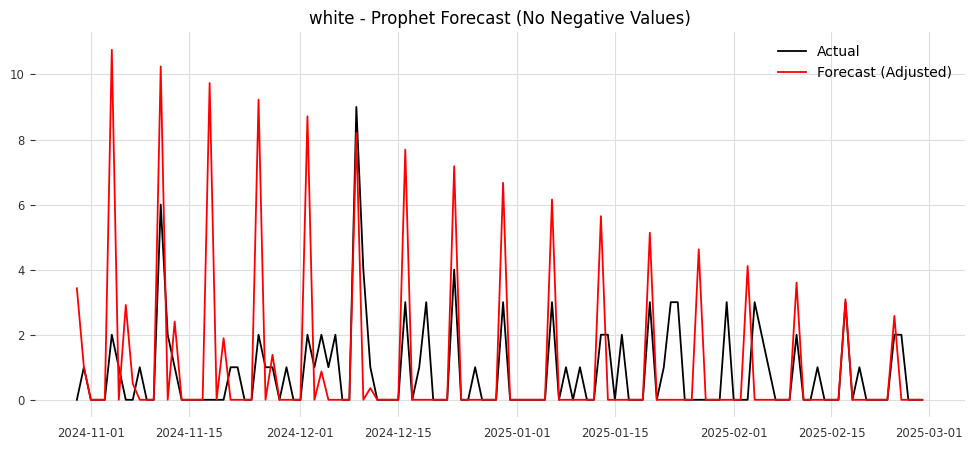

18:29:19 - cmdstanpy - INFO - Chain [1] start processing
18:29:19 - cmdstanpy - INFO - Chain [1] done processing


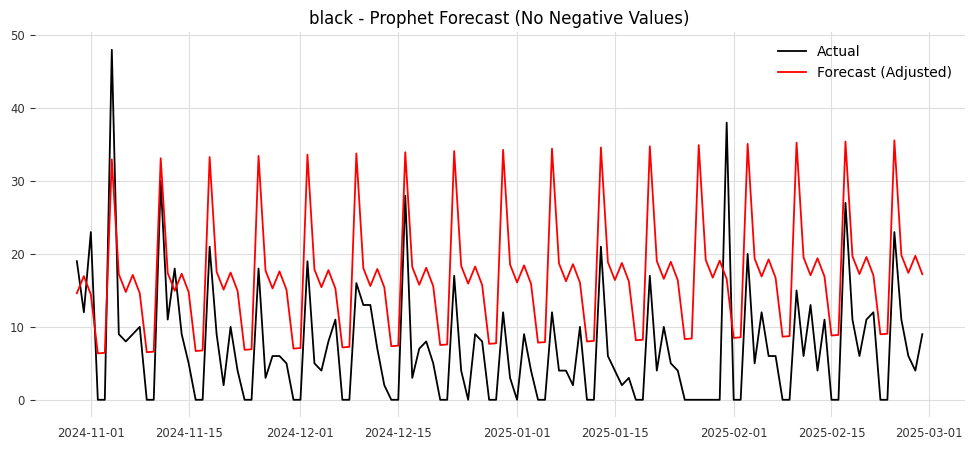

18:29:20 - cmdstanpy - INFO - Chain [1] start processing
18:29:20 - cmdstanpy - INFO - Chain [1] done processing


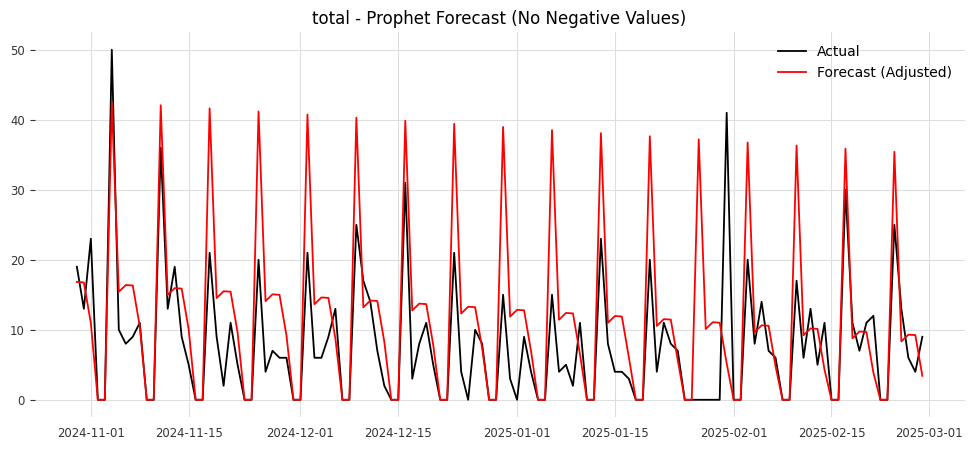

In [11]:
# 실행
target_cols = ['white', 'black', 'total']
for col in target_cols:
    prophet_forecast(df.copy(), col)

# 3. Croston
- "수요 크기"와 "수요 발생 간격"을 각각 따로 예측해서 결합해 계산
- y^t+h=평균 수요 크기/평균 수요 간격
  - 즉, 미래의 모든 시점에 대해 같은 값을 예측하게 됨 → 직선
 
> 예측값이 10으로 나왔다면,
> - 이는 Croston이 과거 데이터를 통해 "10단위 수요가 평균 1회마다 한 번씩 나타날 것이다"
라고 판단한 것과 같음 → 미래 예측은 매 시점마다 10이 됨

In [17]:
def croston_forecast(df, col, test_ratio=0.2):
    # ✅ 중복 날짜를 평균으로 집계 + 결측치 0으로 대체
    series = (
        df[['date', col]]
        .groupby('date', as_index=False)
        .mean()
        .fillna({col: 0})
    )

    # TimeSeries 생성
    ts = TimeSeries.from_dataframe(
        series,
        time_col='date',
        value_cols=col,
        fill_missing_dates=True,
        freq='D'
    )

    # Train/Test split
    split_idx = int(len(ts) * (1 - test_ratio))
    train, test = ts[:split_idx], ts[split_idx:]

    # Croston 모델 학습 및 예측
    model = Croston()
    model.fit(train)
    forecast = model.predict(len(test))

    # 시각화
    plt.figure(figsize=(12, 5))
    test.plot(label='Actual', color='black')
    forecast.plot(label='Forecast', color='red')
    plt.title(f'{col} - Croston Forecast')
    plt.legend()
    plt.grid(True)
    plt.show()

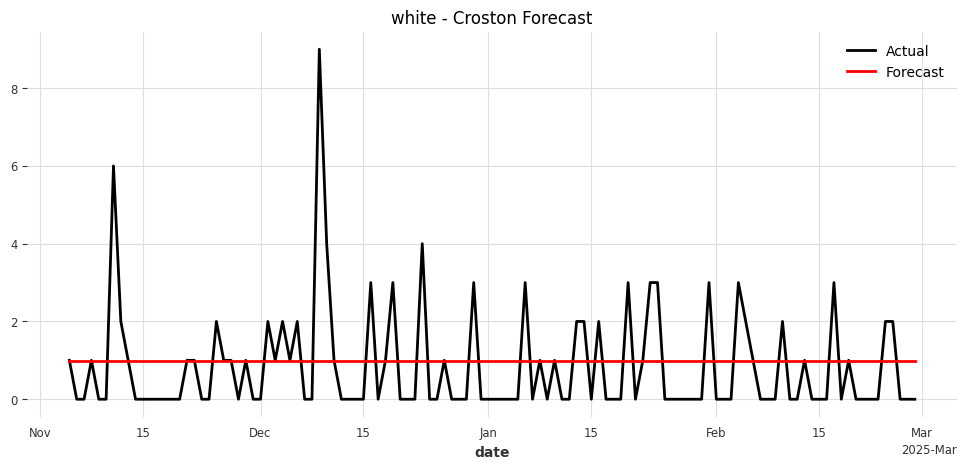

In [18]:
croston_forecast(df, 'white')

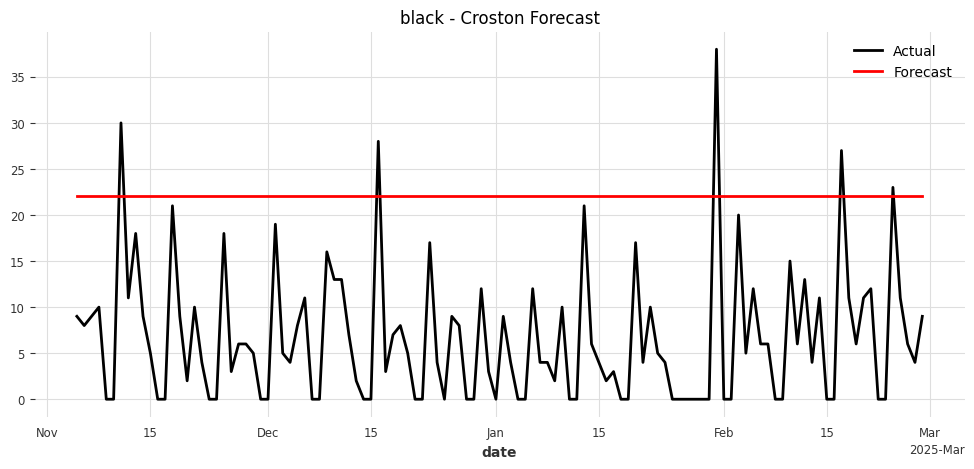

In [19]:
croston_forecast(df, 'black')

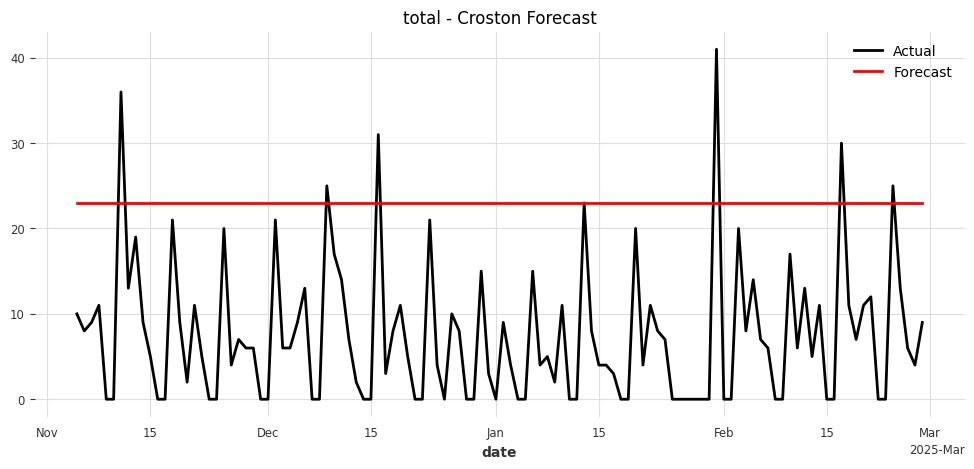

In [20]:
croston_forecast(df, 'total')

# 4. VARIMA (Vector ARIMA)
- 다변량 시계열 예측 (여러 변수 상호 영향 포함)

### 0425 피드백
> 코드 수정 전: train 데이터로만 모델을 학습하고, test 전구간을 한 번에 예측
> - 예를 들면 test 데이터가 100일치라면, 처음 학습한 모델로 100일을 한 번에 쭉 예측하는 방식

→ 예측할 때 7일 단위로 슬라이딩하면서, 매번 최신 데이터로 다시 학습하거나 업데이트해서 점진적으로 더 좋은 예측을 하고자 한다!
- train 데이터로 처음 학습
- 7일치만 예측
- 그 7일을 실제 데이터로 채워서 다시 학습 (또는 업데이트)
- 다음 7일을 예측
- 반복

In [11]:
def varima_forecast_sliding(df, cols, test_ratio=0.2, sliding_window=7):
    df = df[['date'] + cols].dropna().drop_duplicates(subset='date')
    df = df.set_index('date').asfreq('D')
    df = df.fillna(0)

    series = TimeSeries.from_dataframe(df)
    
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    history = train
    forecasts = []

    model = VARIMA(4,1,4) # 초기 모델 fit
    model.fit(history)

    for i in range(0, len(test), sliding_window):
        n_predict = min(sliding_window, len(test) - i)

        forecast = model.predict(n_predict)
        forecasts.append(forecast)

        # update: 예측 끝난 부분까지 실제 test data를 추가
        history = history.append(test[i:i+n_predict])

        # 모델 재학습 (원래 VARIMA는 incremental learning이 어려워서 다시 fit)
        model = VARIMA(4,1,4)
        model.fit(history)

    # 모든 작은 forecasts를 이어붙임
    forecast_all = forecasts[0]
    for f in forecasts[1:]:
        forecast_all = forecast_all.append(f)

    # 시각화
    for col in cols:
        plt.figure(figsize=(12, 5))
        test[col].plot(label='Actual', color='black')
        forecast_all[col].plot(label='Sliding VARIMA Forecast', color='red')
        plt.title(f'{col} - VARIMA Sliding Forecast')
        plt.legend()
        plt.grid(True)
        plt.show()


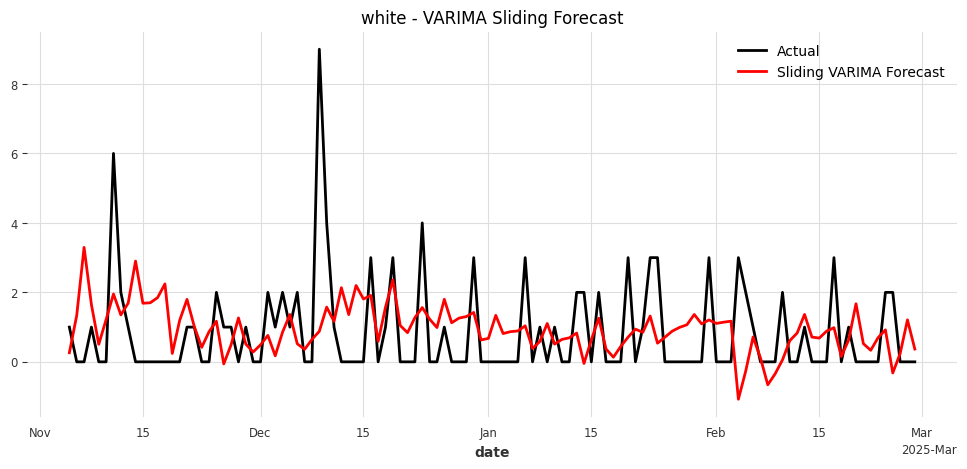

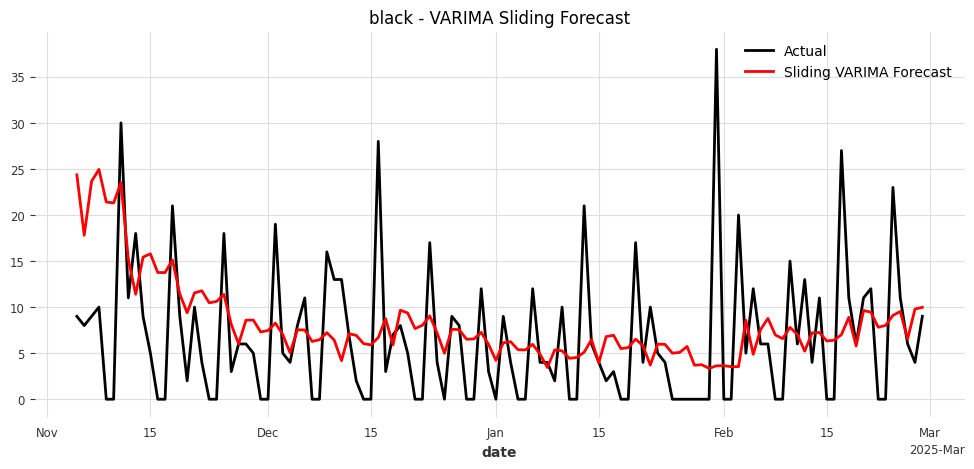

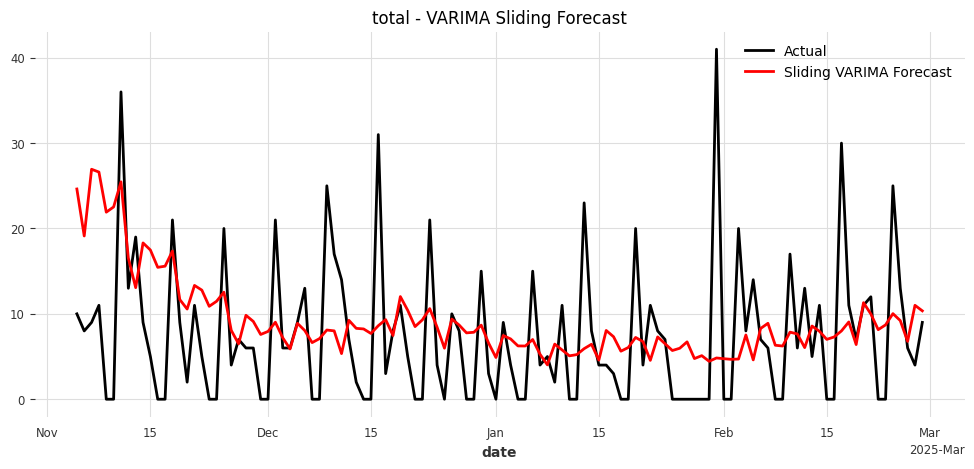

In [12]:
varima_forecast_sliding(df, ['white', 'black', 'total'])

# 5. SARIMA → 0425 제외

- 비계절성 구성:
    - p: AR(자기회귀) 차수
    - d: 차분 횟수 (추세 제거)
    - q: MA(이동 평균) 차수

- 계절성 구성 (seasonal part):
    - P: 계절 AR 차수
    - D: 계절 차분
    - Q: 계절 MA 차수
    - m: 계절 주기 (예: 주간이면 7, 월간이면 12)

In [9]:
def sarima_forecast(df, col, test_ratio=0.2):
    df = df.set_index('date')
    series = df[col]

     # ✅ 결측치를 0으로 채움 (간헐적 수요 유지)
    series = series.fillna(0)
    
    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    # 모델 학습
    model = auto_arima(train, seasonal=True, m=7, stepwise=True, suppress_warnings=True)
    forecast = model.predict(n_periods=len(test))

    # 비계절 p,d,q - 계절 p,d,q,m
    print(f"[{col}] Selected SARIMA Order: {model.order} | Seasonal Order: {model.seasonal_order}")

    # 시각화 (예측값과 실제 test 값만 표시)
    plt.figure(figsize=(12, 5))
    plt.plot(test.index, test, label='Actual', color='black')
    plt.plot(test.index, forecast, label='Forecast', color='red')
    plt.title(f'{col} - Test vs Forecast')
    plt.legend()
    plt.grid(True)
    plt.show()

[white] Selected SARIMA Order: (0, 1, 1) | Seasonal Order: (0, 0, 2, 7)


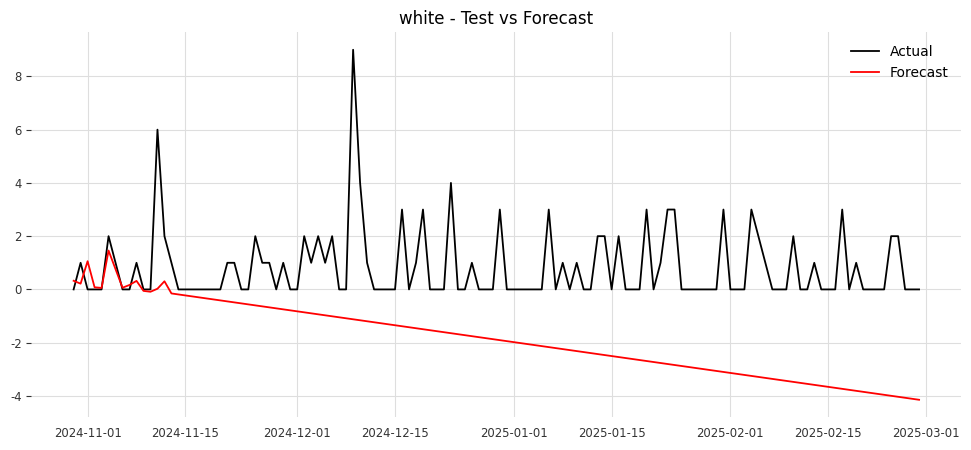

[black] Selected SARIMA Order: (0, 1, 1) | Seasonal Order: (2, 0, 0, 7)


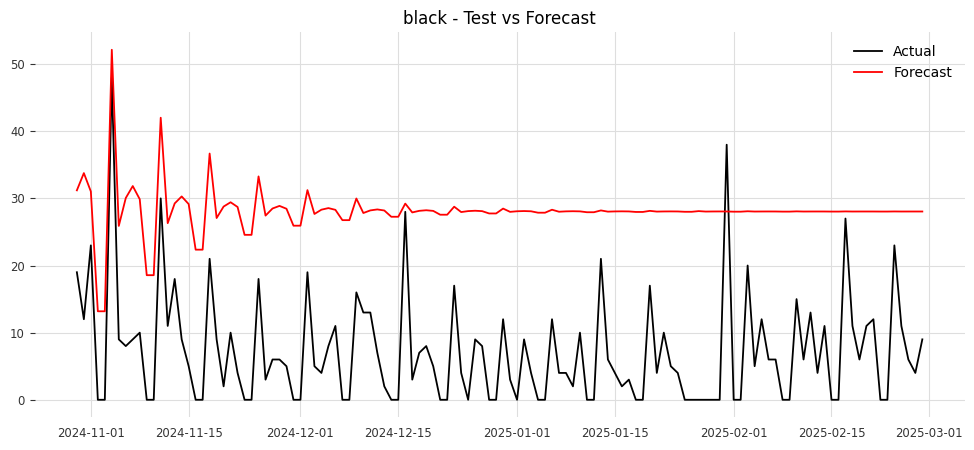

[total] Selected SARIMA Order: (0, 1, 2) | Seasonal Order: (2, 0, 2, 7)


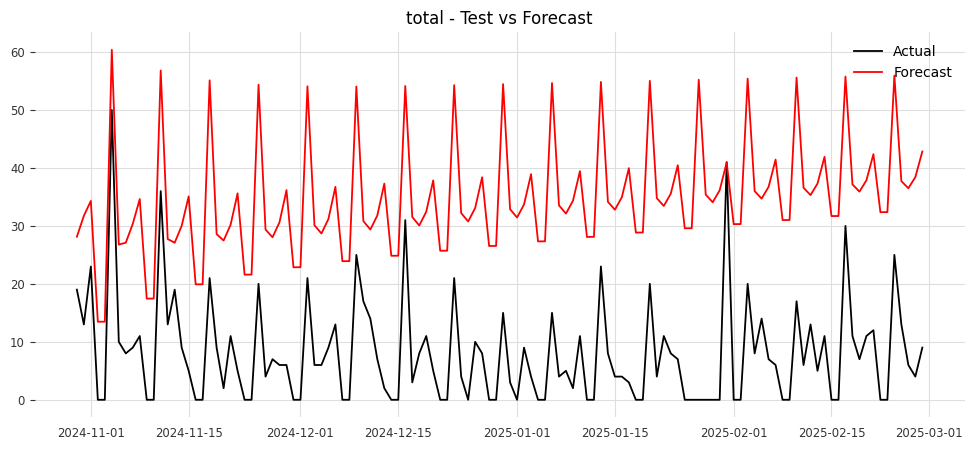

[total_with_safety] Selected SARIMA Order: (2, 1, 5) | Seasonal Order: (2, 0, 1, 7)


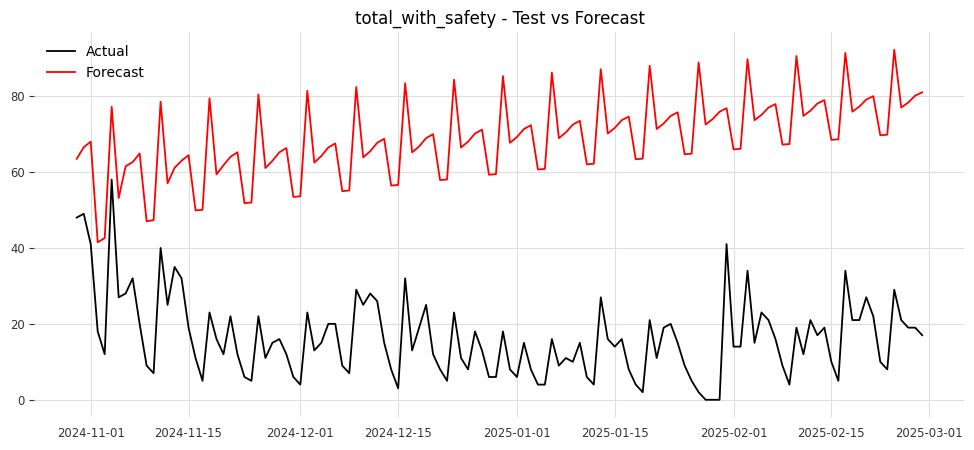

In [10]:
# 대상 컬럼별 반복 예측
target_cols = ['white', 'black', 'total', 'total_with_safety']
for col in target_cols:
    sarima_forecast(df.copy(), col)